In [1]:
# import torch
#
# print("PyTorch GPU 사용 가능 여부:", torch.cuda.is_available())
# print("GPU 이름:", torch.cuda.get_device_name(0))

In [2]:
# import keras
# from sklearn.model_selection import train_test_split
# import torch
#
# print("Keras 버전:", keras.__version__)
# print("PyTorch GPU 인식:", torch.cuda.is_available())

In [3]:
import os
os.environ["KERAS_BACKEND"] = "torch"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import keras
from sklearn.model_selection import train_test_split

print("적용된 Keras 백엔드:", keras.config.backend())

적용된 Keras 백엔드: torch


In [4]:
import keras
from sklearn.model_selection import train_test_split

In [5]:
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

In [6]:
model = keras.Sequential()

In [7]:
model.add(keras.layers.Input(shape=(28, 28, 1)))

In [8]:
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'))

In [9]:
model.add(keras.layers.MaxPooling2D(2))

In [10]:
model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'))

In [11]:
model.add(keras.layers.MaxPooling2D(2))

In [12]:
model.add(keras.layers.Flatten())

In [13]:
model.add(keras.layers.Dense(100, activation='relu'))

In [14]:
model.add(keras.layers.Dropout(0.4))

In [15]:
model.add(keras.layers.Dense(10, activation='softmax'))

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
keras.utils.plot_model(model, show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [18]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('best-cnn-model.keras', save_best_only=True)

early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

history = model.fit(train_scaled, train_target, epochs=20,
                    validation_data=(val_scaled, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7418 - loss: 0.7197 - val_accuracy: 0.8747 - val_loss: 0.3449
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8724 - loss: 0.3592 - val_accuracy: 0.8986 - val_loss: 0.2785
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8900 - loss: 0.3020 - val_accuracy: 0.9062 - val_loss: 0.2534
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9046 - loss: 0.2649 - val_accuracy: 0.9112 - val_loss: 0.2410
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9145 - loss: 0.2362 - val_accuracy: 0.9125 - val_loss: 0.2400
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9218 - loss: 0.2162 - val_accuracy: 0.9191 - val_loss: 0.2186
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9251 - loss: 0.2002 - val_accuracy: 0.9198 - val_loss: 0.2231
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9291 - loss: 0.1872 -

In [19]:
import matplotlib.pyplot as plt

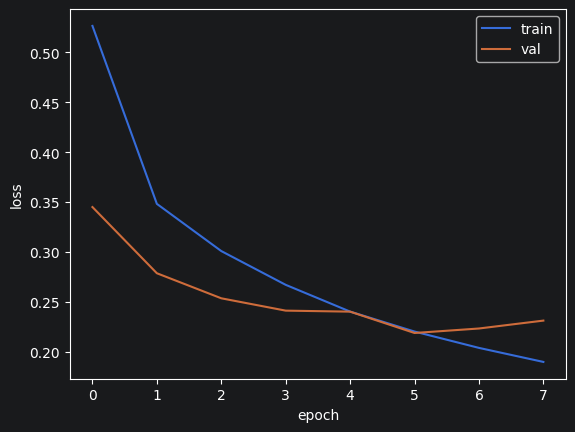

In [20]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch',)
plt.ylabel('loss')
plt.legend()
plt.show()

In [21]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9212 - loss: 0.2144


[0.21861161291599274, 0.9190833568572998]

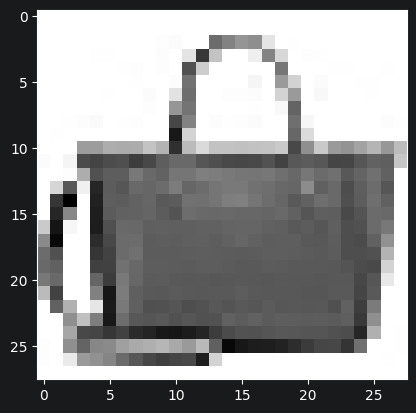

In [22]:
plt.imshow(val_scaled[0].reshape(28, 28), cmap='gray_r')
plt.show()

In [23]:
prds = model.predict(val_scaled[0:1])
print(prds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
[[1.0720835e-13 6.3073168e-20 1.0273839e-15 1.6120477e-14 4.0881164e-16
  2.7874201e-14 2.9989933e-14 1.1710512e-15 1.0000000e+00 1.7187585e-13]]


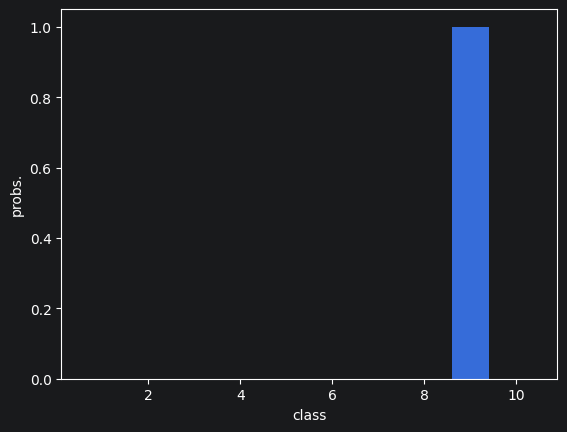

In [24]:
plt.bar(range(1, 11), prds[0])
plt.xlabel('class')
plt.ylabel('probs.')
plt.show()

In [25]:
classes = ['티셔츠', '바지', '스웨터', '드레스', '코트', '샌달', '셔츠', '스니커즈', '가방', '앵클 부츠']

In [26]:
import numpy as np

In [27]:
print(classes[np.argmax(prds)])

가방


In [28]:
test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0

In [29]:
model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9086 - loss: 0.2470


[0.24046079814434052, 0.9120000004768372]